In [153]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
import xgboost as xgb


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('insurance_claims.csv')


df = df.drop(columns=['_c39'])

print(df.shape)
df.head()

(1000, 39)


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,0,?,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,N


In [154]:
nan_counts = df.isna().sum()
print("NaN counts per column:")
print(nan_counts)

nan_counts_df = pd.DataFrame({
    'column': df.columns,
    'nan_count': df.isna().sum().values,
    'nan_percentage': (df.isna().sum() / len(df) * 100).values
})
print("\nNaN statistics:")
print(nan_counts_df)

NaN counts per column:
months_as_customer              0
age                             0
policy_number                   0
policy_bind_date                0
policy_state                    0
policy_csl                      0
policy_deductable               0
policy_annual_premium           0
umbrella_limit                  0
insured_zip                     0
insured_sex                     0
insured_education_level         0
insured_occupation              0
insured_hobbies                 0
insured_relationship            0
capital-gains                   0
capital-loss                    0
incident_date                   0
incident_type                   0
collision_type                  0
incident_severity               0
authorities_contacted          91
incident_state                  0
incident_city                   0
incident_location               0
incident_hour_of_the_day        0
number_of_vehicles_involved     0
property_damage                 0
bodily_injuries          

In [155]:
# Replace NaN with categorical value that other built-in encoder functions would recognize

print(df['authorities_contacted'].unique())
df['authorities_contacted'] = df['authorities_contacted'].fillna('None/Unknown')
print(df['authorities_contacted'].unique())

['Police' nan 'Fire' 'Other' 'Ambulance']
['Police' 'None/Unknown' 'Fire' 'Other' 'Ambulance']


In the function below for preprocessing some select categirucal columns are dropped entirely -- potentially they can be transformed mroe efficiently yielding some more data, by generalization of underlying row. For example policy_number may be generalized to some specific group and be of much smaller cardinality and still hold some generalization power (WIP)

In [156]:
# Preprocessing is done in this functions

class FraudDetectionTransformer:
    """Feature transformation pipeline"""
    
    def __init__(self):
        self.numerical_cols = []
        self.categorical_cols = []
        self.scaler = StandardScaler()
        self.label_encoders = {}
        self.feature_names = []
        
    def fit(self, X, y=None):
        """Fit transformers only training data"""
        
        self.numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
        self.categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
        
        # Remove date columns and high-cardinality columns
        date_cols = [col for col in X.columns if 'date' in col.lower()]
        high_cardinality_cols = ['incident_location', 'incident_city', 'insured_zip', 
                                 'auto_model', 'policy_number']
        
        cols_to_remove = date_cols + high_cardinality_cols
        
        for col in cols_to_remove:
            if col in self.numerical_cols:
                self.numerical_cols.remove(col)
            if col in self.categorical_cols:
                self.categorical_cols.remove(col)
        
        # Fit scaler on numerical columns
        if self.numerical_cols:
            self.scaler.fit(X[self.numerical_cols])
        
        # Fit label encoders on categorical columns
        for col in self.categorical_cols:
            le = LabelEncoder()
            le.fit(X[col].astype(str))
            self.label_encoders[col] = le
        
        self.feature_names = self.numerical_cols + self.categorical_cols
        return self
    
    def transform(self, X):
        """Transform data using fitted transformers"""
        X_transformed = X.copy()
        
        # Scale numerical columns
        if self.numerical_cols:
            X_transformed[self.numerical_cols] = self.scaler.transform(X[self.numerical_cols])
        
        # Encode categorical columns
        for col in self.categorical_cols:
            X_transformed[col] = self.label_encoders[col].transform(X[col].astype(str))
        
        return X_transformed[self.feature_names]
    
    def fit_transform(self, X, y=None):
        """Fit and transform in one step"""
        return self.fit(X, y).transform(X)



In [157]:
# Prepare features and target
X = df.drop(['fraud_reported', 'policy_bind_date', 'incident_date'], axis=1)
y = (df['fraud_reported'] == 'Y').astype(int)

print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"Fraud rate: {y.mean():.2%}")

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit transformer on training data only
transformer = FraudDetectionTransformer()
X_train_transformed = transformer.fit_transform(X_train)
X_test_transformed = transformer.transform(X_test)

print(f"\nTraining set size: {X_train_transformed.shape}")
print(f"Test set size: {X_test_transformed.shape}")



Target distribution:
fraud_reported
0    753
1    247
Name: count, dtype: int64
Fraud rate: 24.70%

Training set size: (800, 31)
Test set size: (200, 31)


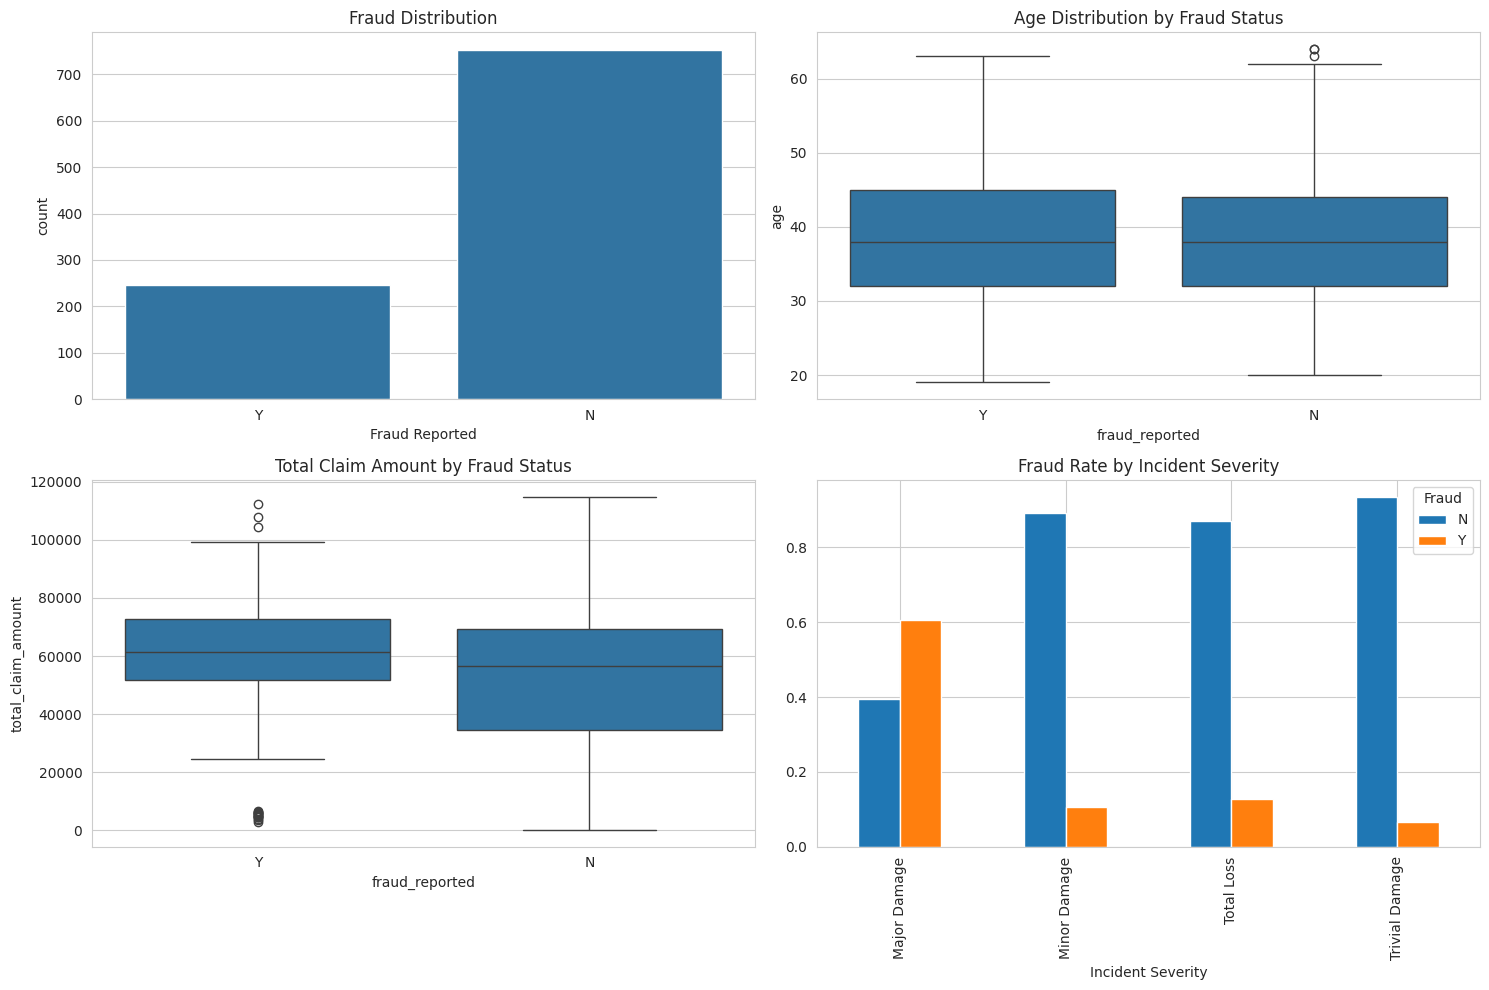

In [158]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Fraud distribution
sns.countplot(data=df, x='fraud_reported', ax=axes[0, 0])
axes[0, 0].set_title('Fraud Distribution')
axes[0, 0].set_xlabel('Fraud Reported')

# Age distribution by fraud
sns.boxplot(data=df, x='fraud_reported', y='age', ax=axes[0, 1])
axes[0, 1].set_title('Age Distribution by Fraud Status')

# Claim amount by fraud
sns.boxplot(data=df, x='fraud_reported', y='total_claim_amount', ax=axes[1, 0])
axes[1, 0].set_title('Total Claim Amount by Fraud Status')

# Incident severity
pd.crosstab(df['incident_severity'], df['fraud_reported'], normalize='index').plot(
    kind='bar', ax=axes[1, 1]
)
axes[1, 1].set_title('Fraud Rate by Incident Severity')
axes[1, 1].set_xlabel('Incident Severity')
axes[1, 1].legend(title='Fraud')

plt.tight_layout()
plt.show()

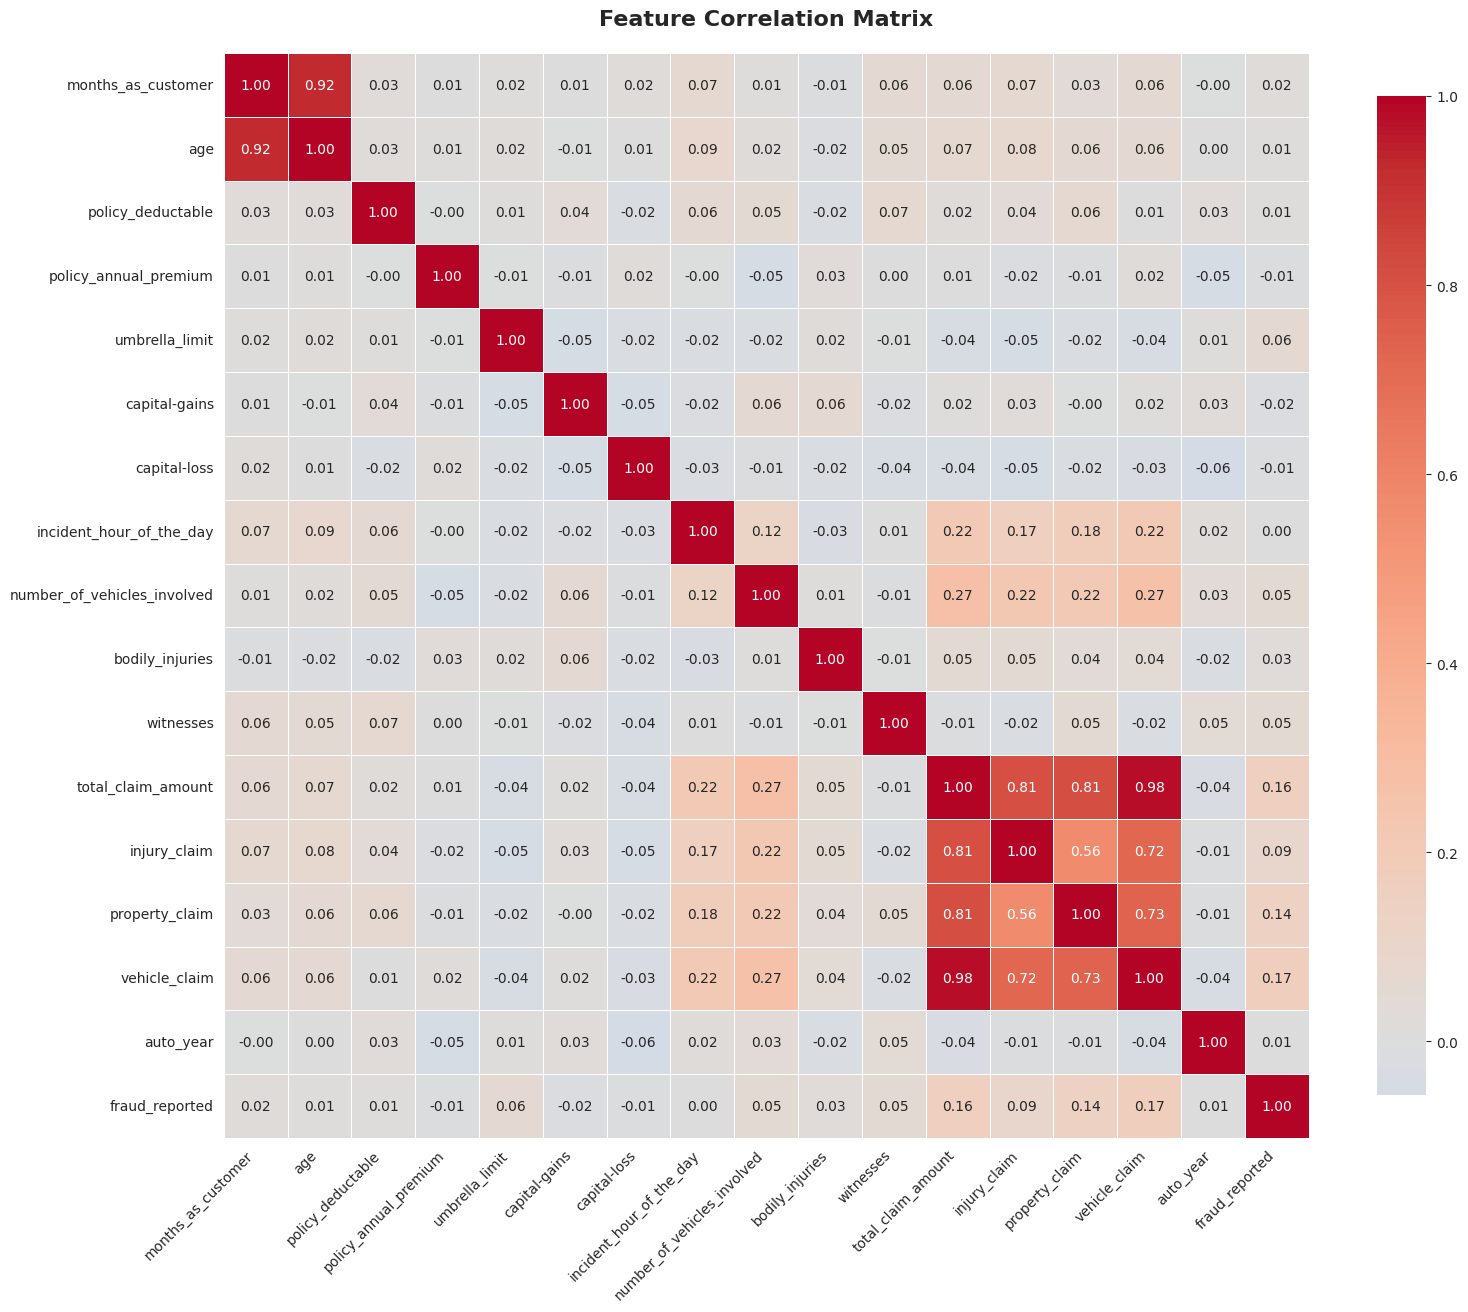

In [159]:
# Create a copy of the data with encoded features for correlation analysis
df_encoded = df.copy()

# Encode target variable
df_encoded['fraud_reported'] = (df_encoded['fraud_reported'] == 'Y').astype(int)

# Select only numerical columns and low-cardinality categoricals for correlation
numerical_features = df_encoded.select_dtypes(include=[np.number]).columns.tolist()

# Remove high-cardinality columns
high_cardinality_cols = ['incident_location', 'incident_city', 'insured_zip', 
                         'auto_model', 'policy_number']
cols_for_corr = [col for col in numerical_features if col not in high_cardinality_cols]

# Calculate correlation matrix
correlation_matrix = df_encoded[cols_for_corr].corr()

# Plot correlation heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()




Top 10 Features Positively Correlated with Fraud:
vehicle_claim                  0.170049
total_claim_amount             0.163651
property_claim                 0.137835
injury_claim                   0.090975
umbrella_limit                 0.058622
number_of_vehicles_involved    0.051839
witnesses                      0.049497
bodily_injuries                0.033877
months_as_customer             0.020544
policy_deductable              0.014817
Name: fraud_reported, dtype: float64

Top 10 Features Negatively Correlated with Fraud:
witnesses                   0.049497
bodily_injuries             0.033877
months_as_customer          0.020544
policy_deductable           0.014817
age                         0.012143
auto_year                   0.007928
incident_hour_of_the_day    0.004316
policy_annual_premium      -0.014480
capital-loss               -0.014863
capital-gains              -0.019173
Name: fraud_reported, dtype: float64


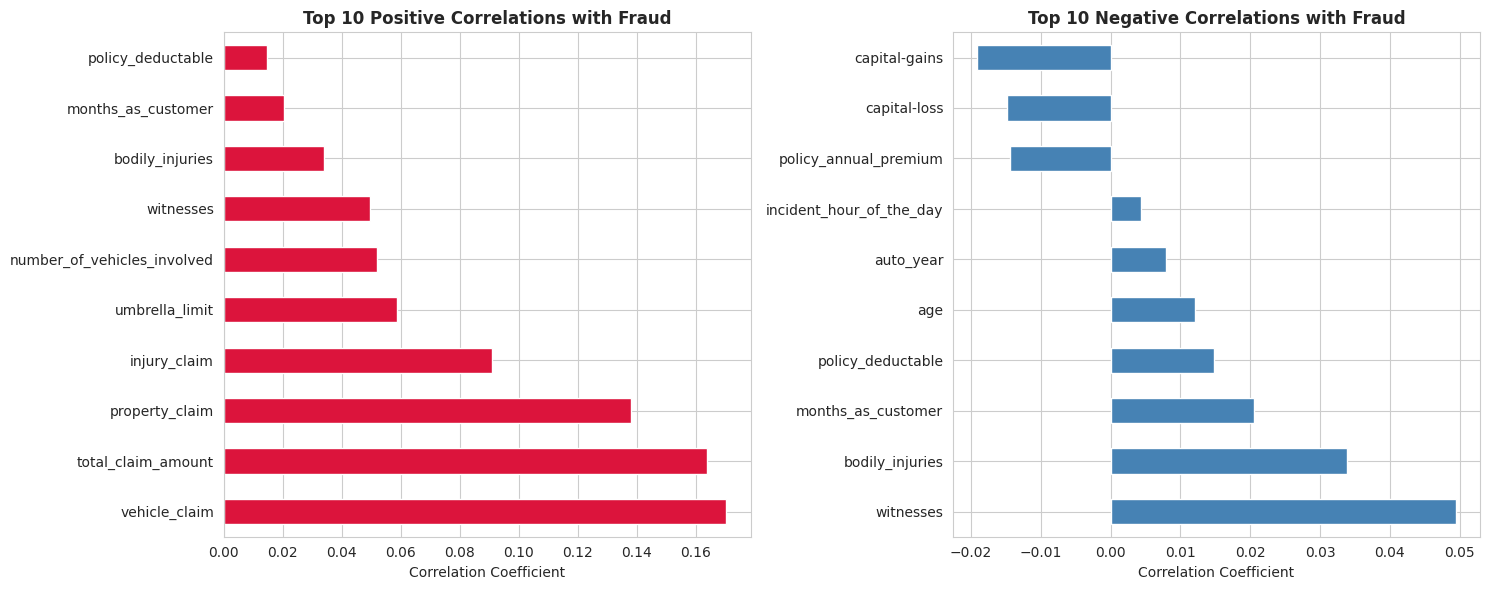

In [160]:
# Show top correlations with target variable
if 'fraud_reported' in correlation_matrix.columns:
    fraud_corr = correlation_matrix['fraud_reported'].drop('fraud_reported').sort_values(ascending=False)
    
    print("\nTop 10 Features Positively Correlated with Fraud:")
    print(fraud_corr.head(10))
    
    print("\nTop 10 Features Negatively Correlated with Fraud:")
    print(fraud_corr.tail(10))
    
    # Plot top correlations with fraud
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Top positive correlations
    fraud_corr.head(10).plot(kind='barh', ax=ax1, color='crimson')
    ax1.set_title('Top 10 Positive Correlations with Fraud', fontweight='bold')
    ax1.set_xlabel('Correlation Coefficient')
    
    # Top negative correlations
    fraud_corr.tail(10).plot(kind='barh', ax=ax2, color='steelblue')
    ax2.set_title('Top 10 Negative Correlations with Fraud', fontweight='bold')
    ax2.set_xlabel('Correlation Coefficient')
    
    plt.tight_layout()
    plt.show()

In [161]:
# Model training functions 

def train_logistic_regression(X_train, y_train, X_test, y_test):
    """Train Logistic Regression with hyperparameter tuning"""
    model = LogisticRegression(
        C=0.1,  # Regularization strength
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    )
    model.fit(X_train, y_train)
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    
    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    return model, y_pred, y_proba, cv_scores

In [162]:
def train_random_forest(X_train, y_train, X_test, y_test):
    """Train Random Forest Classifier with hyperparameter tuning"""
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    
    # Cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    
    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    return model, y_pred, y_proba, cv_scores

In [163]:
def train_xgboost(X_train, y_train, X_test, y_test):
    """Train XGBoost Classifier with hyperparameter tuning"""
    from sklearn.model_selection import GridSearchCV
    import numpy as np
    
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    
    # Grid search parameters
    param_grid = {
        'n_estimators': [50, 100, 200, 250],
        'max_depth': [3, 4, 5, 6],
        'learning_rate': [0.001, 0.01, 0.1],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
    
    base_model = xgb.XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        device='cuda'
    )
    
    # Grid search with k-fold CV
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=3,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1
    )
    
    try:
        X_gpu = cudf.DataFrame.from_pandas(X_train)
        y_gpu = cudf.DataFrame.from_pandas(y_train)
        grid_search.fit(X_gpu, y_gpu)
    except:
        base_model.set_params(tree_method='hist', device='cpu')
        grid_search = GridSearchCV(
            estimator=base_model,
            param_grid=param_grid,
            cv=3,
            scoring='roc_auc',
            n_jobs=-1,
            verbose=1
        )
        grid_search.fit(X_train, y_train)
    
    model = grid_search.best_estimator_
    
    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")
    
    # Cross-validation with best model
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    
    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Plot hyperparameter tuning results
    results_df = pd.DataFrame(grid_search.cv_results_)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: n_estimators vs ROC-AUC
    grouped = results_df.groupby('param_n_estimators')['mean_test_score'].mean()
    axes[0, 0].plot(grouped.index, grouped.values, 'o-', linewidth=2, markersize=8)
    axes[0, 0].set_xlabel('n_estimators', fontsize=11)
    axes[0, 0].set_ylabel('Mean ROC-AUC', fontsize=11)
    axes[0, 0].set_title('Number of Trees vs Performance', fontsize=12, fontweight='bold')
    axes[0, 0].grid(alpha=0.3)
    
    # Plot 2: max_depth vs ROC-AUC
    grouped = results_df.groupby('param_max_depth')['mean_test_score'].mean()
    axes[0, 1].plot(grouped.index, grouped.values, 'o-', linewidth=2, markersize=8, color='orange')
    axes[0, 1].set_xlabel('max_depth', fontsize=11)
    axes[0, 1].set_ylabel('Mean ROC-AUC', fontsize=11)
    axes[0, 1].set_title('Tree Depth vs Performance', fontsize=12, fontweight='bold')
    axes[0, 1].grid(alpha=0.3)
    
    # Plot 3: learning_rate vs ROC-AUC
    grouped = results_df.groupby('param_learning_rate')['mean_test_score'].mean()
    axes[1, 0].plot(grouped.index, grouped.values, 'o-', linewidth=2, markersize=8, color='green')
    axes[1, 0].set_xlabel('learning_rate', fontsize=11)
    axes[1, 0].set_ylabel('Mean ROC-AUC', fontsize=11)
    axes[1, 0].set_title('Learning Rate vs Performance', fontsize=12, fontweight='bold')
    axes[1, 0].set_xscale('log')
    axes[1, 0].grid(alpha=0.3)
    
    # Plot 4: Top 10 parameter combinations
    top_results = results_df.nsmallest(10, 'rank_test_score')[['params', 'mean_test_score']]
    param_labels = []
    for params in top_results['params'].values:
        label = f"n={params['n_estimators']}, d={params['max_depth']}, lr={params['learning_rate']}"
        param_labels.append(label)
    axes[1, 1].barh(param_labels, top_results['mean_test_score'].values, color='steelblue')
    axes[1, 1].set_xlabel('Mean ROC-AUC', fontsize=11)
    axes[1, 1].set_title('Top 10 Parameter Configurations', fontsize=12, fontweight='bold')
    axes[1, 1].grid(alpha=0.3, axis='x')
    axes[1, 1].tick_params(axis='y', labelsize=9)
    
    plt.tight_layout()
    plt.show()
    
    return model, y_pred, y_proba, cv_scores

In [164]:
# PREDICTION FUNCTIONS

def predict_fraud_lr(model, transformer, X_new):
    """Make predictions using trained Logistic Regression"""
    X_transformed = transformer.transform(X_new)
    return model.predict_proba(X_transformed)[:, 1]

def predict_fraud_rf(model, transformer, X_new):
    """Make predictions using trained Random Forest"""
    X_transformed = transformer.transform(X_new)
    return model.predict_proba(X_transformed)[:, 1]

def predict_fraud_xgb(model, transformer, X_new):
    """Make predictions using trained XGBoost"""
    X_transformed = transformer.transform(X_new)
    return model.predict_proba(X_transformed)[:, 1]


TRAINING MODELS

1. Training Logistic Regression...
   Cross-validation scores metrics: 0.7319 (+/- 0.0547)

2. Training Random Forest...
   Cross-validation scores metrics: 0.8406 (+/- 0.0386)

3. Training XGBoost with Hyperparameter Tuning...
Fitting 3 folds for each of 192 candidates, totalling 576 fits

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
Best CV ROC-AUC: 0.8756


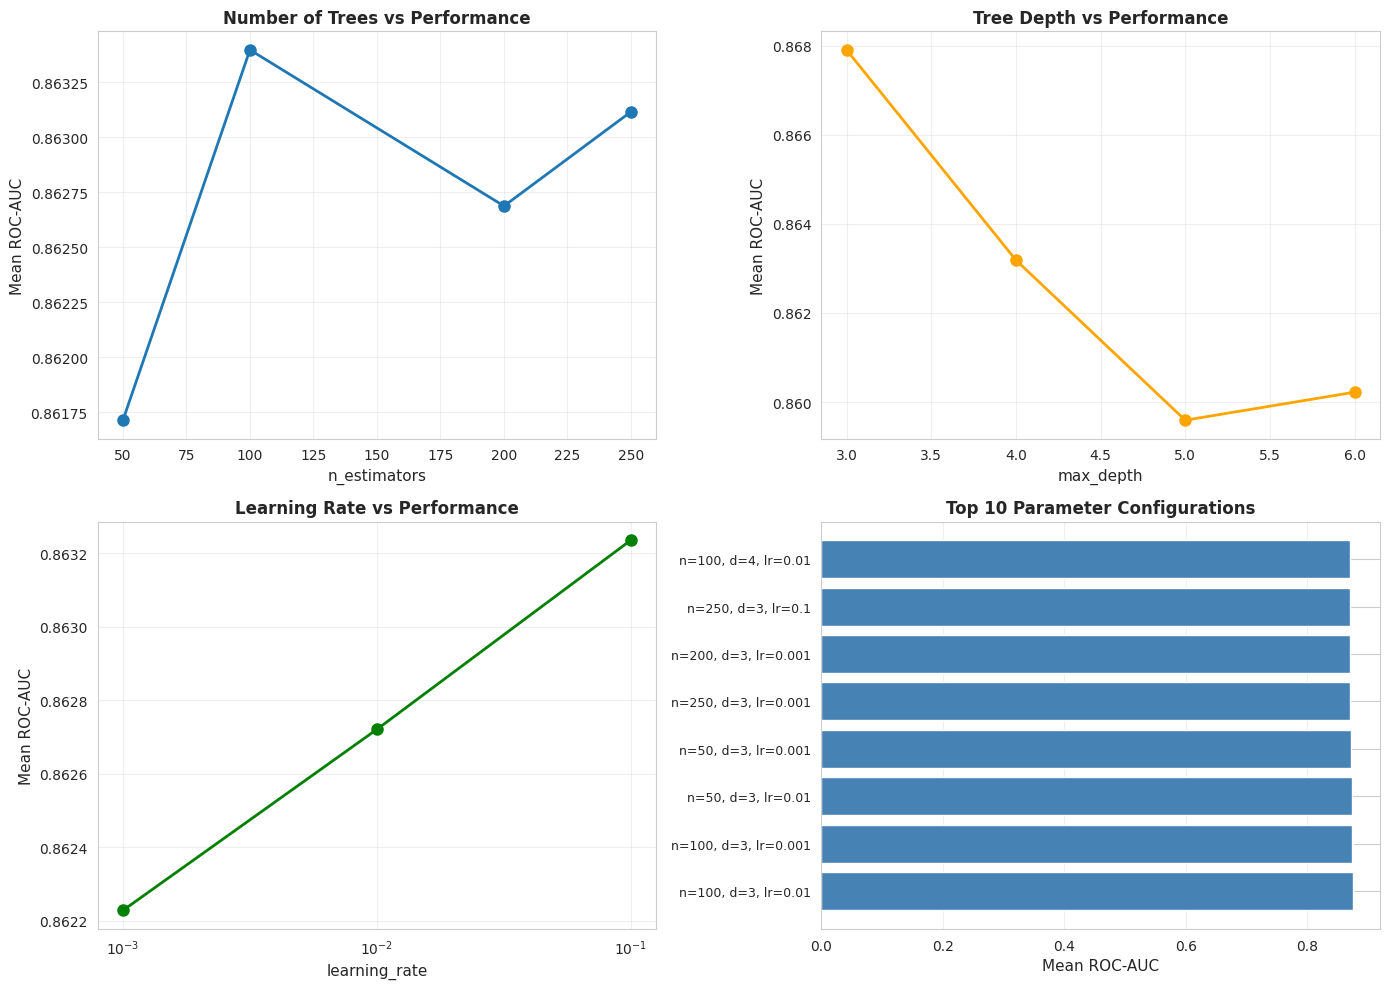

   Cross-validation ROC-AUC: 0.8747 (+/- 0.0324)


In [165]:
# TRAIN ALL MODELS

print("\n" + "="*80)
print("TRAINING MODELS")
print("="*80)

# Train Logistic Regression
print("\n1. Training Logistic Regression...")
lr_model, lr_pred, lr_proba, lr_cv = train_logistic_regression(
    X_train_transformed, y_train, X_test_transformed, y_test
)
print(f"   Cross-validation scores metrics: {lr_cv.mean():.4f} (+/- {lr_cv.std():.4f})")

# Train Random Forest
print("\n2. Training Random Forest...")
rf_model, rf_pred, rf_proba, rf_cv = train_random_forest(
    X_train_transformed, y_train, X_test_transformed, y_test
)
print(f"   Cross-validation scores metrics: {rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})")

# Train XGBoost with grid search
print("\n3. Training XGBoost with Hyperparameter Tuning...")
xgb_model, xgb_pred, xgb_proba, xgb_cv = train_xgboost(
    X_train_transformed, y_train, X_test_transformed, y_test
)
print(f"   Cross-validation ROC-AUC: {xgb_cv.mean():.4f} (+/- {xgb_cv.std():.4f})")

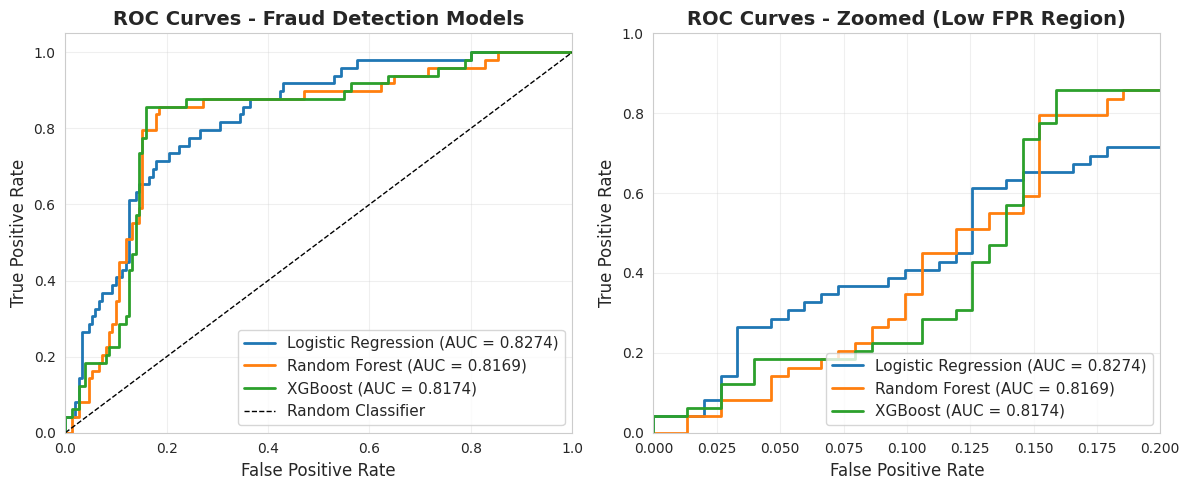

In [166]:
# EVALUATION AND ROC CURVES
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_proba)
lr_auc = auc(lr_fpr, lr_tpr)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
rf_auc = auc(rf_fpr, rf_tpr)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_proba)
xgb_auc = auc(xgb_fpr, xgb_tpr)

# Create figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# First subplot: Full ROC curves
ax1 = axes[0]
ax1.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.4f})', linewidth=2)
ax1.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.4f})', linewidth=2)
ax1.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.4f})', linewidth=2)
ax1.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curves - Fraud Detection Models', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right", fontsize=11)
ax1.grid(alpha=0.3)

# Second subplot: Zoomed ROC curve for low FPR region
ax2 = axes[1]
ax2.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.4f})', linewidth=2)
ax2.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.4f})', linewidth=2)
ax2.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.4f})', linewidth=2)
ax2.set_xlim([0.0, 0.2])
ax2.set_ylim([0.0, 1.0])
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('ROC Curves - Zoomed (Low FPR Region)', fontsize=14, fontweight='bold')
ax2.legend(loc="lower right", fontsize=11)
ax2.grid(alpha=0.3)

# Adjust layout and display
plt.tight_layout()
plt.show()

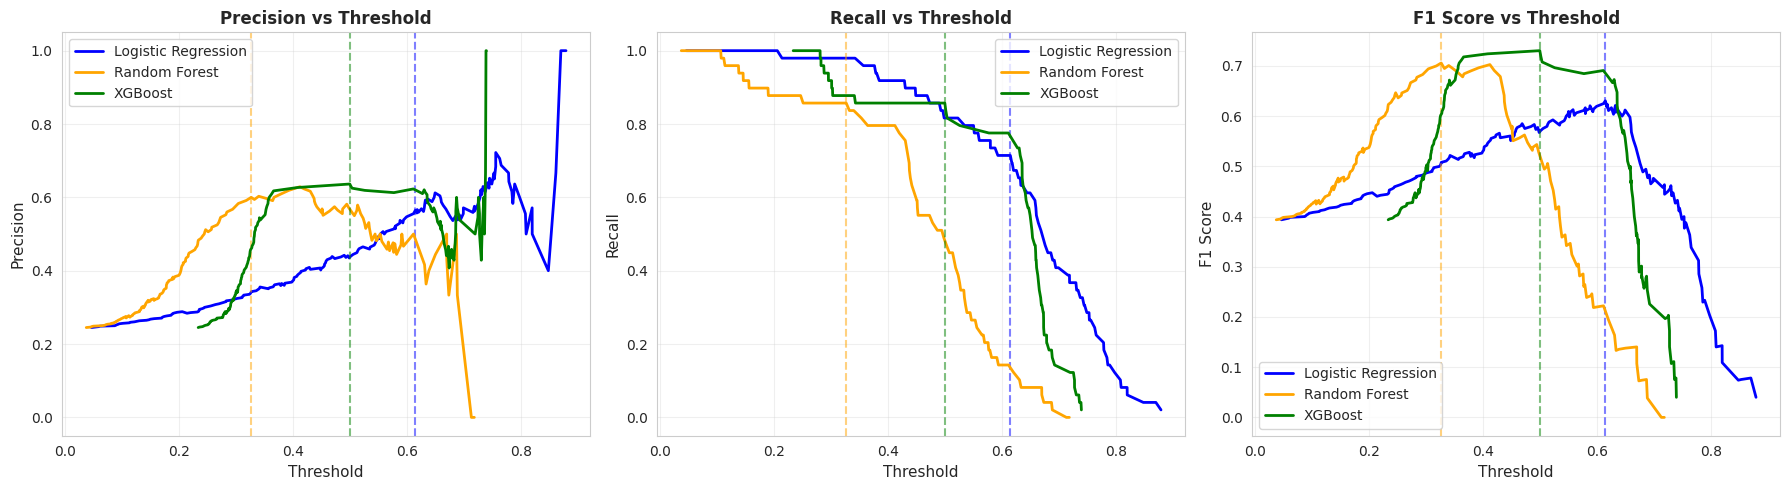

In [167]:
# Precision-Recall-F1 analysis with threshold tuning
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Calculate metrics across thresholds for each model
models_data = [
    ('Logistic Regression', lr_proba, 'blue'),
    ('Random Forest', rf_proba, 'orange'),
    ('XGBoost', xgb_proba, 'green')
]

optimal_thresholds = {}

for idx, (model_name, probas, color) in enumerate(models_data):
    precisions, recalls, thresholds = precision_recall_curve(y_test, probas)
    
    # Calculate F1 for each threshold
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    
    # Optimal threshold: maximize F1 score
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    optimal_thresholds[model_name] = optimal_threshold
    
    # Plot Precision vs Threshold
    axes[0].plot(thresholds, precisions[:-1], label=model_name, linewidth=2, color=color)
    axes[0].axvline(optimal_threshold, linestyle='--', alpha=0.5, color=color)
    
    # Plot Recall vs Threshold
    axes[1].plot(thresholds, recalls[:-1], label=model_name, linewidth=2, color=color)
    axes[1].axvline(optimal_threshold, linestyle='--', alpha=0.5, color=color)
    
    # Plot F1 vs Threshold
    axes[2].plot(thresholds, f1_scores, label=model_name, linewidth=2, color=color)
    axes[2].axvline(optimal_threshold, linestyle='--', alpha=0.5, color=color)

axes[0].set_xlabel('Threshold', fontsize=11)
axes[0].set_ylabel('Precision', fontsize=11)
axes[0].set_title('Precision vs Threshold', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Threshold', fontsize=11)
axes[1].set_ylabel('Recall', fontsize=11)
axes[1].set_title('Recall vs Threshold', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

axes[2].set_xlabel('Threshold', fontsize=11)
axes[2].set_ylabel('F1 Score', fontsize=11)
axes[2].set_title('F1 Score vs Threshold', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [172]:
# Print optimal thresholds and metrics
print("\n=== Optimal Thresholds (Max F1) ===")
for model_name, probas in [('Logistic Regression', lr_proba), 
                             ('Random Forest', rf_proba), 
                             ('XGBoost', xgb_proba)]:
    threshold = optimal_thresholds[model_name]
    y_pred_optimal = (probas >= threshold).astype(int)
    
    precision = precision_score(y_test, y_pred_optimal)
    recall = recall_score(y_test, y_pred_optimal)
    f1 = f1_score(y_test, y_pred_optimal)
    
    print(f"\n{model_name}:")
    print(f"  Threshold: {threshold:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")


=== Optimal Thresholds (Max F1) ===

Logistic Regression:
  Threshold: 0.6144
  Precision: 0.5645
  Recall:    0.7143
  F1 Score:  0.6306

Random Forest:
  Threshold: 0.3269
  Precision: 0.6000
  Recall:    0.8571
  F1 Score:  0.7059

XGBoost:
  Threshold: 0.4996
  Precision: 0.6364
  Recall:    0.8571
  F1 Score:  0.7304


In [173]:
# SUMMARY TABLE

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, y_pred, y_proba, cv_scores in [
    ('Logistic Regression', lr_pred, lr_proba, lr_cv),
    ('Random Forest', rf_pred, rf_proba, rf_cv),
    ('XGBoost', xgb_pred, xgb_proba, xgb_cv)
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc,
        'CV ROC-AUC': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })

results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  CV ROC-AUC   CV Std
Logistic Regression      0.70   0.439560 0.816327  0.571429 0.827409    0.731880 0.054710
      Random Forest      0.78   0.560976 0.469388  0.511111 0.816867    0.840595 0.038588
            XGBoost      0.84   0.630769 0.836735  0.719298 0.817408    0.874654 0.032450


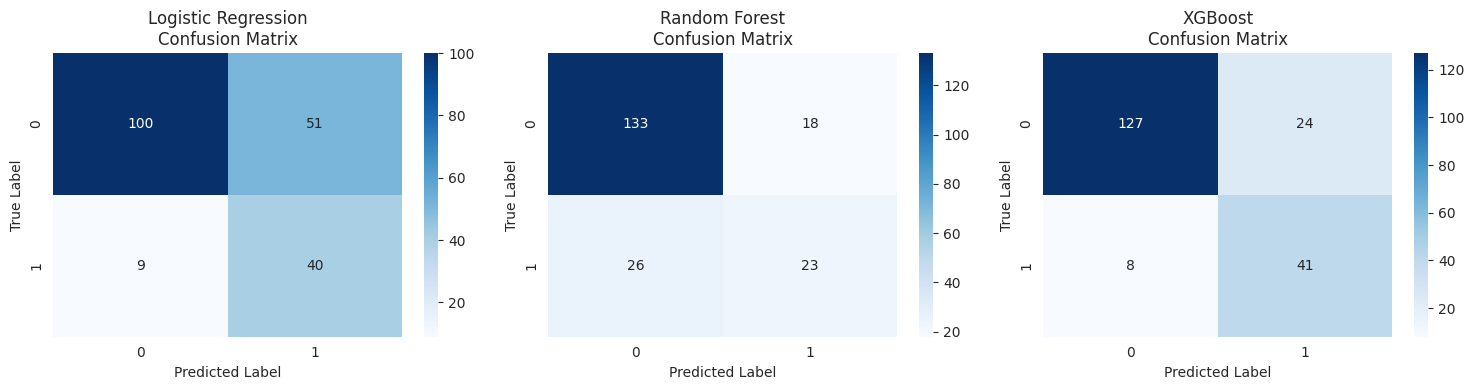

In [174]:
# CONFUSION MATRICES

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, y_pred) in enumerate([
    ('Logistic Regression', lr_pred),
    ('Random Forest', rf_pred),
    ('XGBoost', xgb_pred)
]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{name}\nConfusion Matrix')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

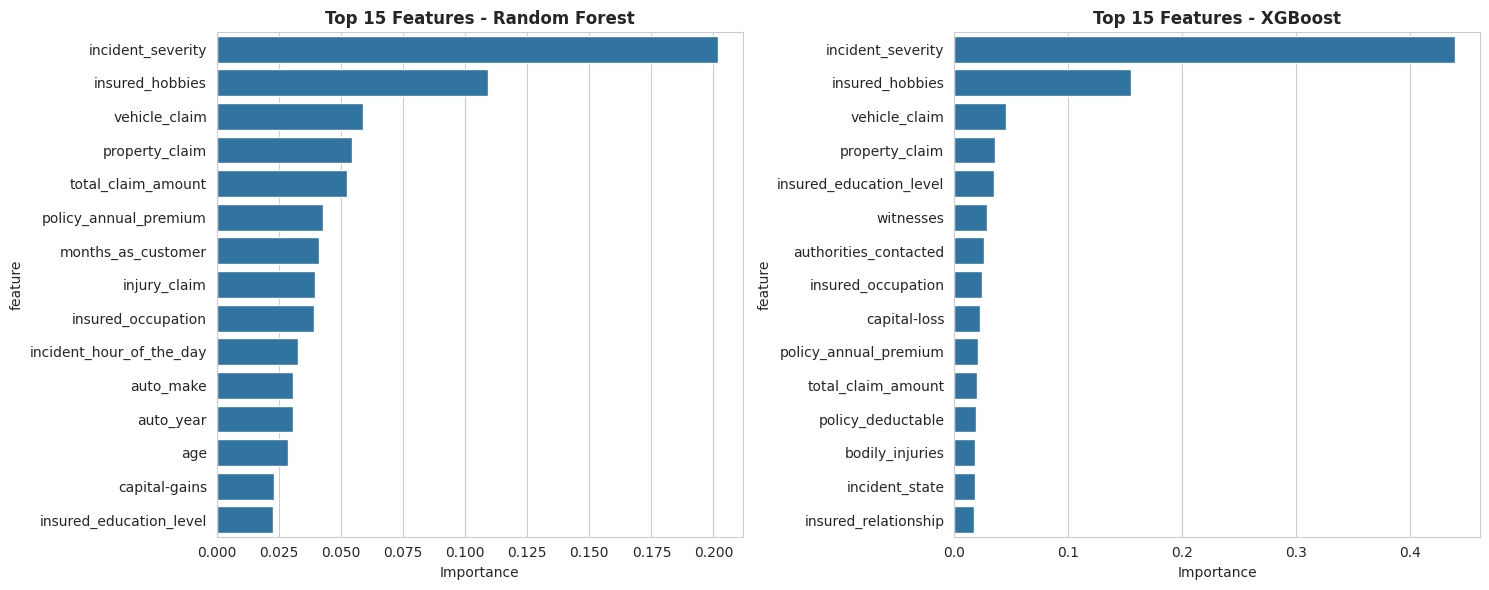

In [175]:
# FEATURE IMPORTANCE (Random Forest and XGBoost)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'feature': transformer.feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

sns.barplot(data=rf_importance, x='importance', y='feature', ax=axes[0])
axes[0].set_title('Top 15 Features - Random Forest', fontweight='bold')
axes[0].set_xlabel('Importance')

# XGBoost Feature Importance
xgb_importance = pd.DataFrame({
    'feature': transformer.feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

sns.barplot(data=xgb_importance, x='importance', y='feature', ax=axes[1])
axes[1].set_title('Top 15 Features - XGBoost', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()